# Random Forest on Iris Dataset

- Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.
- Instead of relying on a single tree, Random Forest builds many trees and combines their predictions.

Advantages:

* Reduces overfitting
* Handles nonlinear relationships
* Works well on classification and regression problems
* Provides feature importance scores
* Robust to noise and outliers

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Load Iris Dataset
The Iris dataset contains measurements from three flower species.
1. Setosa
2. Versicolor
3. Virginica

In [15]:
data = load_iris()

In [3]:
X = data.data
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [4]:
y = data.target
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
feature_names = data.feature_names
feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [6]:
class_names = data.target_names
class_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 112
Testing Samples: 38


## Build Random Forest Model

In [8]:
rf = RandomForestClassifier(            
    max_depth=None,  # Maximum depth of each tree.
    random_state=42, # Produces reproducible results.
    n_estimators=100        # Number of trees in the forest
)

## Train Model

In [9]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction, Accuracy, Confusion Matrix, Classification Report
A `confusion matrix` compares actual values (rows) with predicted values (columns). Diagonal values represent correct predictions.

**Metrics**

- `Precision`: Measures how many predicted positives are actually positive.
- `Recall`: Measures how many actual positives are correctly identified.
- `F1 Score`: Harmonic mean of Precision and Recall.
- `Support`: Number of samples belonging to each class.

In [10]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Performance\n\nAccuracy: {round(acc,4)}")

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

cr= classification_report(y_test,y_pred)
print(f"\nClassification Report:\n{cr}")

Random Forest Performance

Accuracy: 0.9211

Confusion Matrix:
[[12  0  0]
 [ 0 12  1]
 [ 0  2 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.86      0.92      0.89        13
           2       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



## Feature Importance
Feature importance measures how much each feature contributes to model predictions.

In [11]:
print("Feature Importance (average across all trees)")

for name, imp in sorted(
    zip(
        feature_names,
        rf.feature_importances_
    ),
    key=lambda x:x[1],
    reverse=True
):

    print(f"{name}: {imp:.4f}")

Feature Importance (average across all trees)
petal length (cm): 0.4328
petal width (cm): 0.4282
sepal length (cm): 0.1150
sepal width (cm): 0.0240


### Visualization

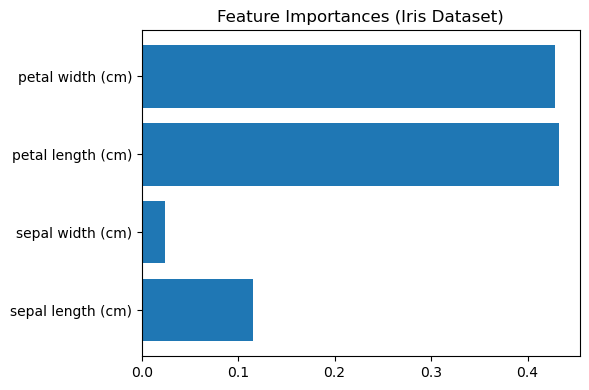

In [12]:
importances = rf.feature_importances_

plt.figure(figsize=(6,4))

plt.barh(
    feature_names,
    importances
)

plt.title(
    "Feature Importances (Iris Dataset)"
)

plt.tight_layout()

plt.savefig(
    "iris_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Effect of Number of Trees
Increasing the number of trees generally improves stability but increases computational cost.

In [13]:
tree_counts = [20, 50, 100, 200]

accuracies = []

best_acc = 0
best_n = None

for n in tree_counts:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)

    acc_n = accuracy_score(
        y_test,
        y_pred
    )

    accuracies.append(acc_n)

    print(
        f"n_estimators={n}: accuracy={acc_n:.4f}"
    )

    if acc_n > best_acc:

        best_acc = acc_n
        best_n = n

print(
    f"\nBest n_estimators selected: {best_n}"
)

n_estimators=20: accuracy=0.8947
n_estimators=50: accuracy=0.9211
n_estimators=100: accuracy=0.9211
n_estimators=200: accuracy=0.8947

Best n_estimators selected: 50


### Visualization

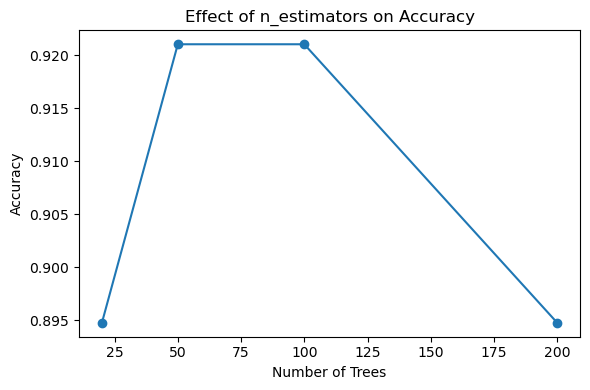

In [14]:
plt.figure(figsize=(6,4))

plt.plot(
    tree_counts,
    accuracies,
    marker="o"
)

plt.xlabel(
    "Number of Trees"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Effect of n_estimators on Accuracy"
)

plt.tight_layout()

plt.savefig(
    "iris_n_estimators_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

In this notebook we learned:

* Random Forest Classification
* Train-Test Split
* Accuracy Evaluation
* Confusion Matrix
* Classification Report
* Feature Importance
* Effect of Number of Trees